# <u>Evaluation</u>

### Prerequisites:
* <a href="Supervised ML Basis.ipynb">Check out the notebook on Supervised ML Basis</a>


## Topics

* [1. Goal](#goal)
* [2. Generalization error of a Learner and fixed model](#GE)
* [3. Inner vs Outer loss](#in_out)
* [4. Training error vs. Test error](#train_test)
* [5. Over-and Underfitting](#over_under)
* [6. Metrics](#metric)
    * [6.1 Regression](#regression)
    * [6.2 Classification](#classification)
* [7. Resampling](#resapmling)
    * [7.1 Hold-out sampling](#hold_out)
    * [7.2 k-fold Cross Validation (CV)](#CV)
    * [7.3 Cross-Validation-Stratification](#CV_strat)
    * [7.4 Leave-one-out CV (LOO-CV)](#LOO-CV)
    * [7.5 Leave-one-object-out](#LOOO)
    * [7.6 Bootstrap](#bootstrap)
* [8. Choosing the right metric](#metric)
* [9. Confusion matrix, ROC and AUC](#extra)


In [ ]:
import numpy as np # for arrays and random numbers

# Create Datasets
from sklearn.datasets import make_regression # create toy data for Regression
from sklearn.datasets import make_classification # create toy data for Classification
from sklearn.datasets import make_blobs # create toy data also for Classification
from sklearn.datasets import make_moons # create toy data also for Classification

# Plotting
import matplotlib.pyplot as plt # for plotting
import plotly.express as px # for plotting
import plotly.graph_objects as go # for plotting

# Train test split
from sklearn.model_selection import train_test_split # split dataset into train and test set

# Metrics for Regression
from sklearn.metrics import (
    mean_squared_error, # MSE
    mean_absolute_error, # MAE
    mean_absolute_percentage_error, # MAPE
    r2_score # R^2
)

# Metric for Classification
from sklearn.metrics import (
    accuracy_score, # Accuracy
    brier_score_loss, # Brier Score
    log_loss, # Log Loss
    confusion_matrix, # TP, FP, FN, TN
    precision_score, # Precision = PPV
    recall_score, # Recall = TPR
    roc_auc_score
)

# Resampling methods
from sklearn.model_selection import (
    KFold, # K-Fold Cross Validation
    StratifiedKFold, # Stratified K-Fold Cross Validation
    LeaveOneOut, # Leave-One-Out Cross Validation
    LeaveOneGroupOut # Leave-One-Group-Out Cross Validation
)
# KFold           -> generic balanced splitting
# StratifiedKFold -> preserves class ratios
# LeaveOneOut     -> one sample left out each time
# LeaveOneGroupOut-> one whole group left out each time

# ML algorithms
from sklearn.neighbors import KNeighborsClassifier # k neares neighbors
from sklearn.preprocessing import PolynomialFeatures # preprocessing for Polynomial regression
from sklearn.linear_model import LinearRegression # perform OLS
from sklearn.tree import DecisionTreeClassifier # for Classification trees
from sklearn.tree import DecisionTreeRegressor # for Regression trees
from sklearn.linear_model import Ridge # Ridge regression
from sklearn.svm import SVC # (non) linear (non)separable SVM
from sklearn.linear_model import LogisticRegression # logistic regression
from sklearn.naive_bayes import GaussianNB # Naive Bayes
from sklearn.ensemble import RandomForestClassifier # Random forest classifier
print("Setup complete")

Setup complete


<a class="anchor" id="goal"></a>
# 1. Goal

- Estimate Generalization Error ($\text{GE}$)

- $\text{GE}(\hat{f},L):=\mathbb{E}\left[L\left(y,\hat{f}(x)\right)\right] \overset{(x,y)\sim \mathbb{P}_{xy}}{\Longrightarrow}$ Expected future model loss ($\mathbb{P}_{xy}$ is data generating process)

- Estimate $\text{GE}(\hat{f},L)$ with $\widehat{\text{GE}}(\hat{f},L):=\frac{1}{m} \sum_{(x,y) \in \mathcal{D}} \left[L\left(y,\hat{f}(x)\right)\right]$ where $| \mathcal{D}| = m$

- Use $(x,y) \in \mathcal{D}_\text{test}$ since if $(x,y) \in \mathcal{D}_\text{train}$ the estimate $\widehat{\text{GE}}(\hat{f},L)$ will be biased

- Problem: No access to unseen data $\Rightarrow$ Divide dataset $\mathcal{D}$ into $\mathcal{D}_\text{train}$ and $\mathcal{D}_\text{test}$

- $\widehat{\text{GE}}(\hat{f},L):= \frac{1}{m} \sum_{(x,y) \in \mathcal{D}_\text{test}} \left[L\left(y,\hat{f}(x)\right)\right]$ where $| \mathcal{D}_\text{test}| = m$ will be unbiased

- $L\left(y,\hat{f}(x)\right)$ always indicates how well the target $y$ mathces the prediction $\hat{f}(x)$

```python
from sklearn.model_selection import train_test_split # to split dataset into train and test set

X_train, X_test, y_train, y_test = train_test_split(
    X, y, # features and target
    test_size=0.2, # proportion used for testing (20%)
    train_size=0.8, # proportion used for training (80%) (optional if test_size given)
    random_state=1414, # ensures reproducible split
    shuffle=True, # randomly shuffle data before splitting
    stratify=y # preserve class proportions in y (useful for classification)
)
```

$$
\overset{\mathcal{D}}{
\begin{array}{ccccccc}
& x_1 & x_2 & \ldots & x_p & y & \hat{y} \\
\hline

& \color{green}x_{11} & \color{green}x_{12} & \ldots & \color{green}x_{1p} & \color{green}y_1 & \\

& \color{green}x_{21} & \color{green}x_{22} & \ldots & \color{green}x_{2p} & \color{green}y_2 & \\

\color{green}\mathcal{D}_\text{train}
& \color{green}x_{31} & \color{green}x_{32} & \ldots & \color{green}x_{3p} & \color{green}y_3 & \\

& \vdots & \vdots & \ddots & \vdots & \vdots & \\

& \color{green}x_{(n-3)1} & \color{green}x_{(n-3)2} & \ldots & \color{green}x_{(n-3)p} & \color{green}y_{n-3} & \\

\hline

& \color{red}x_{(n-2)1} & \color{red}x_{(n-2)2} & \ldots & \color{red}x_{(n-2)p} & \color{red}y_{n-2} & \hat{y} \\

\color{red}\mathcal{D}_\text{test}
& \color{red}x_{(n-1)1} & \color{red}x_{(n-1)2} & \ldots & \color{red}x_{(n-1)p} & \color{red}y_{n-1} & \hat{y} \\

& \color{red}x_{n1} & \color{red}x_{n2} & \ldots & \color{red}x_{np} & \color{red}y_n & \hat{y} \\
\end{array}
}
$$

<p align="center">
<img src="pics/1.png" width="600"/>
</p>



In [2]:
np.random.seed(1914) 
n, dim = 10, 3 # sample size and numbe of dimensions
X = np.random.randint(1,100,dim*n).reshape(-1,dim) # two features
y = X @ np.array([0.2,1.2,2]) + np.random.normal(0,1)
print("X=\n",X)
print("\ny=\n",y)

def my_train_test_split(X, y, train_size=0.7, random_state=None, shuffle=True):
    if not (0 < train_size < 1):
        raise ValueError("train_size must be between 0 and 1")

    n = len(y)
    if X.shape[0] != n:
        raise ValueError("X and y must have same length")

    # reproducibility
    rng = np.random.default_rng(random_state)

    indices = np.arange(n)
    if shuffle:
        indices = rng.permutation(n)

    split = int(n * train_size)

    train_idx = indices[:split]
    test_idx = indices[split:]

    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]

X_train,y_train,X_test,y_test = my_train_test_split(X,y,random_state=1941,shuffle=False)
print("X_train=\n",X_train)
print("\ny_train=\n",y_train)
print("X_test=\n",X_test)
print("\ny_test=\n",y_test)

X=
 [[22 47 37]
 [39 44 69]
 [13 28 34]
 [69 49 25]
 [43 75 24]
 [12 73 31]
 [59 83 47]
 [28 11 65]
 [33 92 38]
 [89 77 18]]

y=
 [132.40321697 196.20321697 101.80321697 120.20321697 144.20321697
 149.60321697 203.00321697 146.40321697 190.60321697 143.80321697]
X_train=
 [[22 47 37]
 [39 44 69]
 [13 28 34]
 [69 49 25]
 [43 75 24]
 [12 73 31]
 [59 83 47]]

y_train=
 [132.40321697 196.20321697 101.80321697 120.20321697 144.20321697
 149.60321697 203.00321697]
X_test=
 [[28 11 65]
 [33 92 38]
 [89 77 18]]

y_test=
 [146.40321697 190.60321697 143.80321697]


<a class="anchor" id="GE"></a>
# 2. Generalization error of a Learner and fixed model

<div style="
<-- -->background-color:rgb(239, 201, 50);;
padding:16px;
border-radius:8px;
color:white;
">

### GE of a Learner $\mathcal{I}$

- Distribution of different models $\hat{f}$ trained on different training datasets

<div style="
<-- -->background-color:rgb(213, 230, 222);
padding:14px;
border-radius:8px;
color:white;
margin-top:12px;
margin-left:24px;
width:85%;
border-left:4px solid rgb(208, 215, 212);
box-shadow: inset 0 0 8px rgba(219, 207, 207, 0.3);
">

### GE of a fixed model

- Single random draw of a fitted model $\hat{f}$
- $\widehat{\text{GE}}(\hat{f},L):= \frac{1}{m} \sum_{(x,y) \in \mathcal{D}_\text{test}}\left[L\left(y,\hat{f}(x)\right)\right] \Rightarrow$ Expected error on unseen data
- "How good is this model outside the training data?"


</div>

- $\text{GE}=$ Expected error of all models $\hat{f}$ over all training datasets
- "How good is the model in the long run?"

</div>

<a class="anchor" id="in_out"></a>
# 3. Inner vs Outer loss

<div style="
<-- -->background-color:#2f4154;
padding:16px;
border-radius:4px;
color:white;
">

### Outer loss (evaluation loss)

- Empirical estimator of the outer/generalization loss on $\mathcal{D}_\text{test}$
- Measures error on unseen data $\mathcal{D}_\text{test}$
- Examples:
    - Mean squarred error: $\rho_\text{MSE}(y,\mathcal{F})=\frac{1}{m} \sum_{i=1}^m (y^{(i)}- \hat{y}^{(i)})^2$ with $\hat{y}^{(i)}=\hat{\theta}^\top x^{(i)}$
    - Mean absolute error: $\rho_\text{MAE}(y,\mathcal{F})=\frac{1}{m} \sum_{i=1}^m \mid y^{(i)}- \hat{y}^{(i)} \mid$
    - Missclassification error: $\rho_\text{MCE}(y,\mathcal{F})=\frac{1}{m} \sum_{i=1}^m [y^{(i)} \neq \hat{y}^{(i)}]$

<div style="
<-- -->background-color:#243341;
padding:14px;
border-radius:8px;
color:white;
margin-top:12px;
margin-left:24px;
width:85%;
border-left:4px solid #7aa6d1;
box-shadow: inset 0 0 8px rgba(0,0,0,0.3);
">

### Inner loss 

- Function the learner actually minimizes during training
- Function chosen because it is differentiable/convex
- Examples:
    - Ordinary least squares: $\hat{\theta}=\arg \min_\theta \sum_{i=1}^m (y^{(i)} -\theta^\top x^{(i)})^2$
    - Log-loss: $L(y,\pi(x \mid \theta))=-y\log(\pi(x \mid \theta)) - (1-y)\log((1-\pi(x \mid \theta)))$
    - Hinge loss: $\max(0,1-y^{(i)}(w^\top x^{(i)} +b))$

**Dangers of using inner loss as outer loss:**
- Surrogate losses live on an arbitrary numerical scale unrelated to the practical target criterion.
    - i.e. hinge loss = 0.4 does not translate to 40% badness
- some inner losses are model-specific surrogate objectives, making cross-model comparison numerically meaningless
    - i.e. log-loss only applies to probabilistic classifier producing estimated class probabilities
</div>

- Minimizing inner loss is intended to indirectly reduce outer loss

</div>

<a class="anchor" id="train_test"></a>
# 4. Training error vs. Test error

<div style="display:flex; gap:5px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--  -->border:2px solid white;
width:50%;
">

<h5 style="text-align:center;">Training error</h5>

$$
\rho(y_\text{train}, \mathcal{F}_\text{train}), 
\mathcal{F}_\text{train}=
\begin{bmatrix} 
\hat{f}_{\mathcal{D}_\text{train}}(x_\text{train}^{(i)}) \\
\vdots \\
\hat{f}_{\mathcal{D}_\text{train}}(x_\text{train}^{(m)}) \\
\end{bmatrix}
$$

- Train error: Often biased (overfitting risk)
- Interpolator = Model that passes exactly through all training points
- Example: Polynomial Regression
    - Polynomial degree $d$ increases $\Rightarrow$ $\rho_\text{MSE}$ on $\mathcal{D}_\text{train}$ decreases 
- Training error decreases with $\begin{cases} \text{smaller training sets} \\ \text{increasing model complexity}  \end{cases}$

<p align="center">
<img src="pics/2.png" width="600"/>
</p>

</div>

<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--  -->border:2px solid white;
width:50%;
">

<h5 style="text-align:center;">Test error</h5>

$$
\rho(y_\text{test}, \mathcal{F}_\text{test}), 
\mathcal{F}_\text{test}=
\begin{bmatrix} 
\hat{f}_{\mathcal{D}_\text{test}}(x_\text{test}^{(i)}) \\
\vdots \\
\hat{f}_{\mathcal{D}_\text{test}}(x_\text{test}^{(m)}) \\
\end{bmatrix}
$$

- Test error: Approximately unbiased when evaluated on many unseen observations drawn from the same population
- Example: Polynomial Regression
    - Polynomial degree $d$ increases $\Rightarrow$ $\rho_\text{MSE}$ on $\mathcal{D}_\text{test}$ forms a $\mathrm{U}$-shape

- Test error decreases with $\rightarrow$ Larger training sets
- Test error $\rightarrow$ Higher variance $\begin{cases} \text{with smaller test sets} \\ \text{with increasing model complexity}  \end{cases}$


<p align="center">
<img src="pics/3.png" width="600"/>
</p>

</div>
</div>

$\underbrace{\text{Hold-out-sampling: Trade-off} \begin{cases} \text{Bigger training set} \rightarrow \text{Lower Bias (better model), higher variance (small test set)} 
\\ 
\text{Bigger test set} \rightarrow \text{Higher Bias (weak model), lower variance (stable test error)}  \end{cases}}_{\text{split ratio determines which effect dominates}}$

- $\text{Bias}(x)=\mathbb{E}_\text{train}\left[\hat{f}(x)\right] - f(x)$
    - $\mathbb{E}_\text{train}\left[\hat{f}(x)\right]$: average prediction of model trained trained across all possible training sets
    - $f(x)$: true function value
- Variance =  Measure of how much the predictions of the model change when trained on different training sets

<p align="center">
<img src="pics/11.png" width="600"/>
</p>

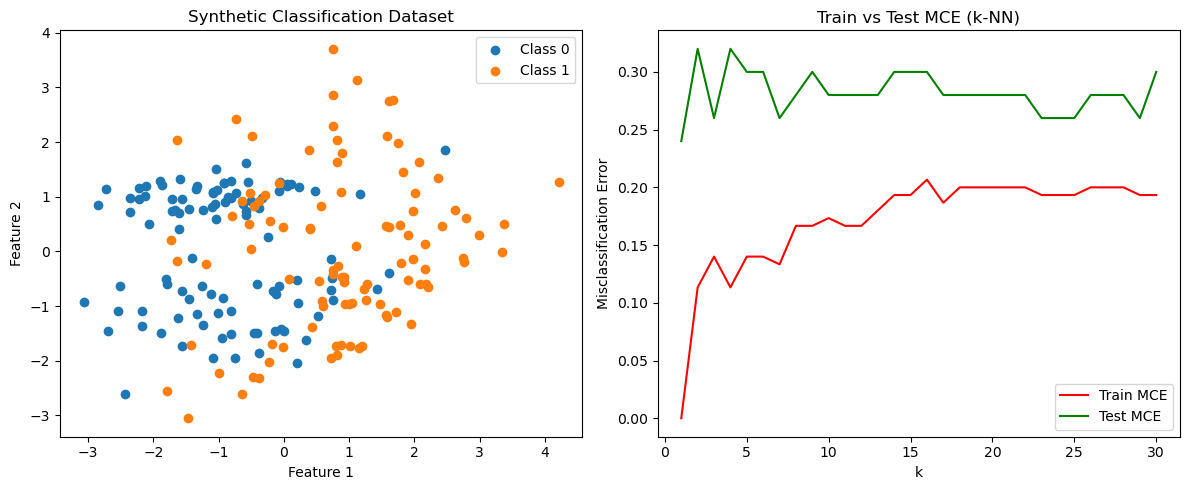

In [3]:
X, y = make_classification(n_samples=200,n_features=2,n_clusters_per_class=2,random_state=2009,n_classes=2,n_informative=2,n_redundant=0)

# Train-test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2022, shuffle=True)

# Evaluate k-NN 
num_neighbors = np.arange(1, 31)

mce_train_list = []
mce_test_list = []

for k in num_neighbors:
    knn_mod = KNeighborsClassifier(n_neighbors=k)
    knn_mod.fit(X_train, y_train)

    train_pred = knn_mod.predict(X_train)
    test_pred = knn_mod.predict(X_test)

    acc_train = np.mean(y_train == train_pred)
    acc_test = np.mean(y_test == test_pred)

    mce_train_list.append(1 - acc_train)
    mce_test_list.append(1 - acc_test)

# Plotting (1x2 grid)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for cls in np.unique(y):
    axes[0].scatter(X[y == cls, 0],X[y == cls, 1],label=f"Class {cls}")

axes[0].set_title("Synthetic Classification Dataset")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].legend()

axes[1].plot(num_neighbors, mce_train_list, label="Train MCE",c="red")
axes[1].plot(num_neighbors, mce_test_list, label="Test MCE",c="green")
axes[1].set_title("Train vs Test MCE (k-NN)")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Misclassification Error")
axes[1].legend()

plt.tight_layout()
plt.show()

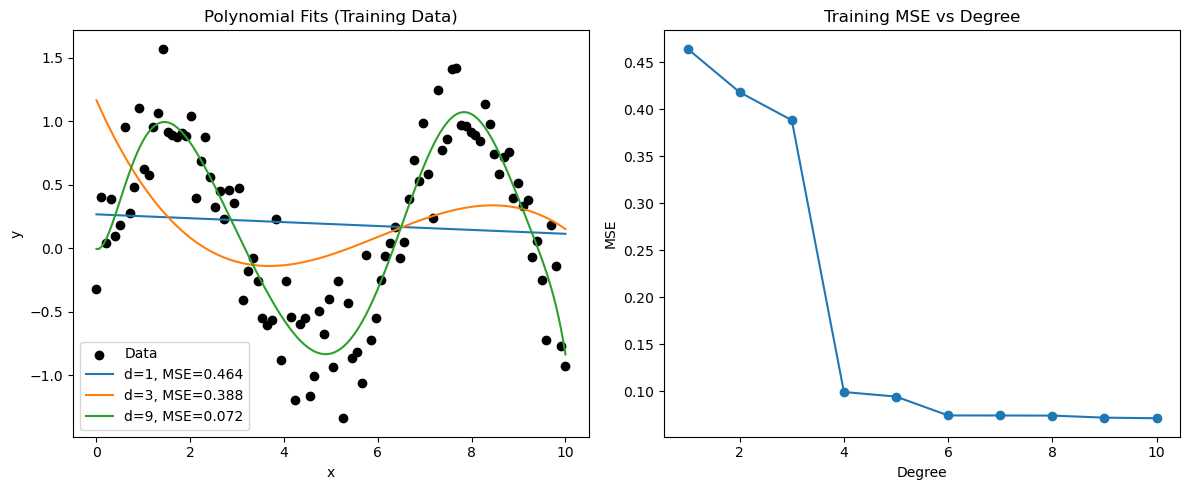

In [4]:
np.random.seed(1428)
n = 100
x = np.linspace(0, 10, n)
y = np.sin(x) + np.random.randn(n) * 0.3

X = x.reshape(-1, 1)

# Create subplots (1x2) 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# Left plot: Fits
axes[0].scatter(x, y, label="Data",c="black")
#axes[0].plot(x, np.sin(x), linestyle="--", label="True function")

degrees = [1, 3, 9]
x_plot = np.linspace(0, 10, 300).reshape(-1, 1)

for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=True)

    X_poly = poly.fit_transform(X)
    model = LinearRegression().fit(X_poly, y)

    train_preds = model.predict(X_poly)
    mse_train = np.mean((y - train_preds) ** 2)

    X_plot_poly = poly.transform(x_plot)
    y_plot = model.predict(X_plot_poly)

    axes[0].plot(x_plot.flatten(),y_plot,label=f"d={degree}, MSE={mse_train:.3f}")

axes[0].set_title("Polynomial Fits (Training Data)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()


# Right plot: MSE vs Degree
degrees_full = np.arange(1, 11)
mse_list = []

for degree in degrees_full:
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    X_poly = poly.fit_transform(X)

    model = LinearRegression().fit(X_poly, y)
    preds = model.predict(X_poly)

    mse = np.mean((y - preds) ** 2)
    mse_list.append(mse)

axes[1].plot(degrees_full, mse_list, marker='o')
axes[1].set_title("Training MSE vs Degree")
axes[1].set_xlabel("Degree")
axes[1].set_ylabel("MSE")

plt.tight_layout()
plt.show()

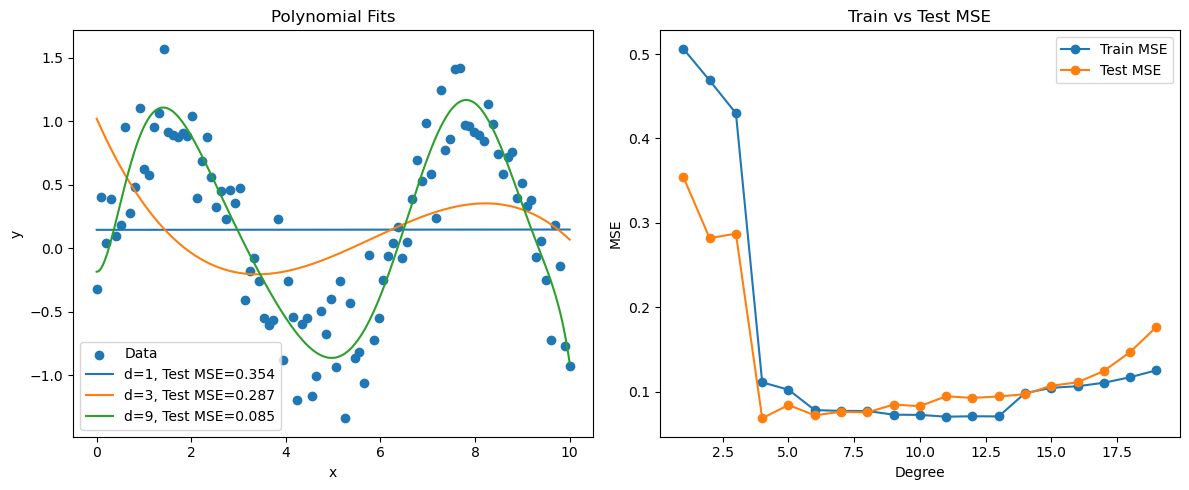

In [5]:
# Data generation
np.random.seed(1428)
n = 100
x = np.linspace(0, 10, n)
y = np.sin(x) + np.random.randn(n) * 0.3

X = x.reshape(-1, 1)

# Train-test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1428, shuffle=True)

# Create subplots 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# Left plot: Polynomial fits
axes[0].scatter(x, y, label="Data")
#axes[0].plot(x, np.sin(x), linestyle="--", label="True function")

degrees = [1, 3, 9]
x_plot = np.linspace(np.min(x), np.max(x), 300).reshape(-1, 1)

for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=True)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression().fit(X_train_poly, y_train)

    # smooth curve
    X_plot_poly = poly.transform(x_plot)
    y_plot = model.predict(X_plot_poly)

    # test MSE for legend
    test_preds = model.predict(X_test_poly)
    mse_test = np.mean((y_test - test_preds) ** 2)

    axes[0].plot(x_plot.flatten(),y_plot,label=f"d={degree}, Test MSE={mse_test:.3f}")

axes[0].set_title("Polynomial Fits")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

# Right plot: Train vs Test MSE
degrees_full = np.arange(1, 20)

mse_train_list = []
mse_test_list = []

for degree in degrees_full:
    poly = PolynomialFeatures(degree=degree, include_bias=True)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression().fit(X_train_poly, y_train)

    train_preds = model.predict(X_train_poly)
    test_preds = model.predict(X_test_poly)

    mse_train = np.mean((y_train - train_preds) ** 2)
    mse_test = np.mean((y_test - test_preds) ** 2)

    mse_train_list.append(mse_train)
    mse_test_list.append(mse_test)

axes[1].plot(degrees_full, mse_train_list, marker='o', label="Train MSE")
axes[1].plot(degrees_full, mse_test_list, marker='o', label="Test MSE")

axes[1].set_title("Train vs Test MSE")
axes[1].set_xlabel("Degree")
axes[1].set_ylabel("MSE")
axes[1].legend()

plt.tight_layout()
plt.show()

<a class="anchor" id="over_under"></a>
# 5. Over-and Underfitting

<div style="display:flex; gap:5px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--  -->border:2px solid white;
width:50%;
">

<h5 style="text-align:center;">Overfitting</h5>

- Small train errors & high test error
- $\text{OF}(\hat{f},L):=\underbrace{\text{GE}(\hat{f},L)}_{\text{(theoretical) GE}}-\underbrace{\mathcal{R}(\hat{f},L)}_{\text{training errors}}$
- Low bias & high variance
- $\text{OF}(\hat{f},L)$ influenced by
    - Complexity of hypothesis space
    - Training set size
    - Dimensionality of feature space

<p align="center">
<img src="pics/12.png" width="600"/>
</p>


</div>

<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--  -->border:2px solid white;
width:50%;
">

<h5 style="text-align:center;">Underfitting</h5>

- High train errors & High test error
- $\text{UF}(\hat{f},L):=\text{GE}(\hat{f},L)-\underbrace{\text{GE}(f^*,L)}_{\text{Bayes optimal model}}$
- model does not reflect true shape of function well
- High bias & low variance

<p align="center">
<img src="pics/13.png" width="600"/>
</p>

</div>
</div>

<p align="center">
<img src="pics/14.png" width="600"/>
</p>


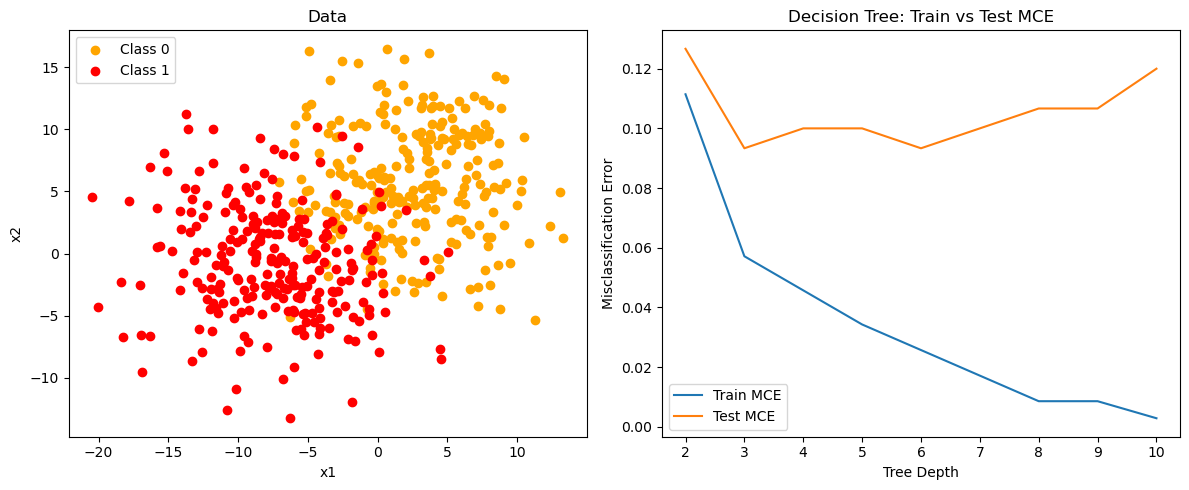

In [6]:
np.random.seed(1522)
n = 500
X, y = make_blobs(n_features=2,centers=2,random_state=1523,cluster_std=4.5,n_samples=n)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1528, shuffle=True, train_size=0.7)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# Data
axes[0].scatter(X[y == 0, 0], X[y == 0, 1], c="orange", label="Class 0")
axes[0].scatter(X[y == 1, 0], X[y == 1, 1], c="red", label="Class 1")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].set_title("Data")
axes[0].legend()


# MCE vs depth
tree_depths = np.arange(2, 11)

train_mce_list = np.zeros(len(tree_depths))
test_mce_list = np.zeros(len(tree_depths))

for i, depth in enumerate(tree_depths):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=1533)
    tree.fit(X_train, y_train)

    train_preds = tree.predict(X_train)
    test_preds = tree.predict(X_test)

    train_mce_list[i] = 1 - np.mean(train_preds == y_train)
    test_mce_list[i] = 1 - np.mean(test_preds == y_test)

axes[1].plot(tree_depths, train_mce_list, label="Train MCE")
axes[1].plot(tree_depths, test_mce_list, label="Test MCE")
axes[1].set_xlabel("Tree Depth")
axes[1].set_ylabel("Misclassification Error")
axes[1].set_title("Decision Tree: Train vs Test MCE")
axes[1].legend()

plt.tight_layout()
plt.show()

<a class="anchor" id="metric"></a>
# 6. Metrics

<a class="anchor" id="regression"></a>
## 6.1 Regression

* SSE: $\rho_\text{SSE}(y,\mathcal{F})=\sum_{i=1}^m (y^{(i)}-\hat{y}^{(i)})^2$

* MSE: $\rho_\text{MSE}(y,\mathcal{F})=\frac{1}{m}\rho_\text{SSE}(y,\mathcal{F})$ (L2-loss)

* Root MSE: $\rho_\text{RMSE}(y,\mathcal{F})=\sqrt{\rho_\text{MSE}(y,\mathcal{F})}$


* MAE: $\rho_\text{MAE}(y,\mathcal{F})=\frac{1}{m}\sum_{i=1}^m \mid y^{(i)}-\hat{y}^{(i)} \mid [0,\infty) $ (L1-loss)

* MAPE: $\rho_\text{MAPE}(y,\mathcal{F})=\frac{1}{m} \mid \frac{y^{(i)}-\hat{y}^{(i)}}{y^{(i)}} \mid$ 

* $R^2$: $\rho_{R^2}(y,\mathcal{F})=1-\frac{\text{SSE}}{\text{SST}}$ where $\text{SST}=\sum_{i=1}^m (y^{(i)}-\bar{y})^2$

* $\rho_\text{Spearmann}(y,\mathcal{F})=\frac{\mathbb{Cov}(\text{rg}(y),\text{rg}(\hat{y}))}{\sqrt{\mathbb{Var}(\text{rg}(y))}\sqrt{\mathbb{Var}(\text{rg}(\hat{y}))}}$ $\in$ $[-1,1]$

```python
from sklearn.metrics import (
    mean_squared_error, # MSE
    mean_absolute_error, # MAE
    mean_absolute_percentage_error, # MAPE
    r2_score # R^2
)

from scipy.stats import spearmanr
import numpy as np

# y_test = true target values
# y_pred = model predictions

# 1. SSE = Sum of Squared Errors
# p_SSE = sum (y_i - prediction_i)^2
SSE = np.sum((y_test - y_pred)**2)


# 2. MSE = Mean Squared Error
# p_MSE = (1/m) * sum (y_i - prediction_i)^2
MSE = mean_squared_error(y_test, y_pred)

# 3. RMSE = Root Mean Squared Error
# p_RMSE = sqrt(MSE)
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))

# 4. MAE = Mean Absolute Error
# p_MAE = (1/m) * sum |y_i - prediction_i|
MAE = mean_absolute_error(y_test, y_pred)


# 5. MAPE = Mean Absolute Percentage Error
# ρ_MAPE = (1/m) * sum |(y_i - prediction_i)/y_i|
MAPE = mean_absolute_percentage_error(y_test, y_pred)


# 6. R^2 = Coefficient of Determination
# p_R² = 1 - SSE/SST
R2 = r2_score(y_test, y_pred)

# 7. Spearman Rank Correlation
# ρ_Spearman = corr(rank(y), rank(prediction_i))
Spearman_corr, p_value = spearmanr(y_test, y_pred)
```


<a class="anchor" id="classification"></a>
## 6.2 Classification

* Accuray: $\rho_\text{ACC}=\frac{1}{m} \sum_{i=1}^m \left[y^{(i)} = \hat{y}^{(i)}\right] \in [0,1]$

* Missclassification error: $\rho_\text{MCE}=1-\rho_\text{ACC}=\frac{1}{m} \sum_{i=1}^m \left[y^{(i)} \neq \hat{y}^{(i)}\right] \in [0,1]$

* Brier score: $\rho_\text{BS}=\frac{1}{m}\sum_{i=1}^m (\hat{\pi}^{(i)}-y^{(i)})^2$

* Log loss: $\rho_\text{LL}=\frac{1}{m}\sum_{i=1}^m -y^{(i)} \log(\hat{\pi}^{(i)}) - (1-y^{(i)}) \log(1-\hat{\pi}^{(i)})$

* Confusion matrix: 
    * True Positive (TP) means that an instance is predicted as positive that is really positive (correct prediction)
    * False Negative (FN) means that an instance is predicted as negative that is actually positive (incorrect prediction)
    * False Positive (FP) means that an instance is predicted as positive that is actually negative (incorrect prediction)
    * True Positive (TN) means that an instance is predicted as negative that is really negative (correct prediction)
$$
\begin{array}{ccc}
&& & y &  \\
&& \color{green}+ &  & \color{red}-  \\
\hline 
&\color{green}+& \text{True positive (TP)} &  & \text{False positive (FP)}  \\
\hat{y}&&&& \\
&\color{red}-& \text{False negative (FN)} &  & \text{True negative (TN)}  \\
\end{array}
$$


$$
\text{Precision}=\frac{\text{TP}}{\text{TP}+\text{FP}}, \quad
\text{Recall}=\frac{\text{TP}}{\text{TP}+\text{FN}}
$$


<p align="center">
<img src="pics\16.png" width="600"/>
</p>

---

<p align="center">
<img src="pics\17.png" width="600"/>
</p>

- Costs: $\frac{1}{n} \sum_{i=1}^n C[y^{(i)},\hat{y}^{(i)}]$

- $\rho_{\text{BS,MC}}=\frac{1}{m} \sum_{i=1}^m \sum_{k=1}^g (\hat{\pi}_k^{(i)}-o_k^{(i)})^2$, $\underbrace{o_k^{(i)}=[y^{(i)}=k]}_{\text{one-hot-encoding}}$

* ROC (Receiver operating characteristics) metrics: 
$$
\begin{array}{ccc}
&& & y &  \\
&& \color{green}+ &  & \color{red}- & \\
\hline 
&\color{green}+& \text{TP} &  & \text{FP} & \rho_{\text{PPV}}  \\
\hat{y}&&&& \\
&\color{red}-& \text{FN} &  & \text{TN} & \rho_{\text{NPV}} \\
\hline 
&& \rho_{\text{TPR}} &  & \rho_{\text{TNR}} & \rho_{\text{ACC}} \\
\end{array}
$$

$$
\rho_{\text{PPV}}=\frac{\text{TP}}{\text{TP + FP}}, \quad
\rho_{\text{TPR}}=\frac{\text{TP}}{\text{TP + FN}} \\[3mm]
\rho_{\text{NPV}}=\frac{\text{TN}}{\text{FN + TN}}, \quad
\rho_{\text{TNR}}=\frac{\text{TN}}{\text{FP + TN}} \\[3mm]
\rho_{\text{ACC}}=\frac{\text{TP} + \text{TN}}{\text{Total}} 
$$



```python
from sklearn.metrics import (
    accuracy_score, # Accuracy
    brier_score_loss, # Brier Score
    log_loss, # Log Loss
    confusion_matrix, # TP, FP, FN, TN
    precision_score, # Precision = PPV
    recall_score, # Recall = TPR
    roc_auc_score)


# y_test      = true class labels (0/1 or multiclass)
# y_pred      = predicted hard labels
# y_proba     = predicted probabilities for positive class
# y_proba_mc  = predicted probability matrix for multiclass shape (m,g)


# 1. Accuracy
# p_ACC = (1/m) sum [y_i = prediction_i]
ACC = accuracy_score(y_test, y_pred)

# 2. Misclassification Error
# p_MCE = 1 - Accuracy
MCE = 1 - accuracy_score(y_test, y_pred)


# 3. Brier Score (binary probabilistic predictions)
# ρ_BS = (1/m) sum (prob_i - y_i)^2
BS = brier_score_loss(y_test, y_proba)


# 4. Log Loss / Cross Entropy
# p_LL = (1/m) sum -y_i log(prob_i) - (1-y_i)log(1-prob_i)
LL = log_loss(y_test, y_proba)


# 5. Confusion Matrix
# [[TN, FP],
#  [FN, TP]]
TN, FP, FN, TP = confusion_matrix(y_test, y_pred).ravel()


# 6. Precision = Positive Predictive Value (PPV)
# TP / (TP + FP)
Precision = precision_score(y_test, y_pred)


# 7. Recall = True Positive Rate (TPR, Sensitivity)
# TP / (TP + FN)
Recall = recall_score(y_test, y_pred)


# 8. Negative Predictive Value (NPV)
# TN / (TN + FN)
NPV = TN / (TN + FN)


# 9. True Negative Rate (TNR, Specificity)
# TN / (TN + FP)
TNR = TN / (TN + FP)


# 10. Cost-sensitive classification
# (requires user-defined cost matrix C)
# C[a,b] = cost of predicting b when truth is a
C = np.array([
    [0, 5],   # true class 0 predicted as 0/1
    [10, 0]   # true class 1 predicted as 0/1
])

Costs = np.mean([C[y_true, y_hat] for y_true, y_hat in zip(y_test, y_pred)])


# 11. Multiclass Brier Score
# ρ_BS,MC = (1/m) sum sum (prob_ik - o_ik)^2
one_hot = np.eye(y_proba_mc.shape[1])[y_test]

BS_MC = np.mean(np.sum((y_proba_mc - one_hot)**2, axis=1))


# 12. ROC-AUC (threshold-independent ranking metric)
ROC_AUC = roc_auc_score(y_test, y_proba)
```


#### Example Costs

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/9.png" width="500"/>
  <img src="pics/10.png" width="500"/>
</div>


<a class="anchor" id="resampling"></a>
# 7. Resampling

- $\widehat{\text{GE}}(\hat{f},L):=\frac{1}{m} \sum_{(x,y) \in \mathcal{D}_\text{test}} \left[L\left(y,\hat{f}(x)\right)\right] $

- $\widehat{\text{GE}}(\hat{f},L)$ unbiased on $\mathcal{D}_\text{test}$ and for i.i.d. $\mathcal{D}_\text{test}$

**Problem:**
- If test set $\mathcal{D}_\text{test}$ is small then $\widehat{\text{GE}}(\hat{f},L):= \frac{1}{m} \sum_{(x,y) \in \mathcal{D}_\text{test}} \left[L\left(y,\hat{f}(x)\right)\right]$ will have high variance (very different values for slightly different small test sets $\mathcal{D}_\text{test}$)

**Possible solutions to decrease variance:**
- Increase test set size $m = |\mathcal{D}_\text{test}|$ $\Rightarrow$ means decreasing size of $\mathcal{D}_\text{train}$ which is bad &#10060;
- Compute $\widehat{\text{GE}}(\hat{f},L)$ for $B$ test sets $\mathcal{D}_\text{test}$ and aggregate them &#9989;
    - B test sets: $\mathcal{J}=\underbrace{((\mathcal{J}_\text{train1},\underbrace{\mathcal{J}_\text{test1}}_{\widehat{\text{GE}}(\hat{f},L)_1}),(\mathcal{J}_\text{train2},\underbrace{\mathcal{J}_\text{test2}}_{\widehat{\text{GE}}(\hat{f},L)_2}),\ldots,(\mathcal{J}_\text{trainB},\underbrace{\mathcal{J}_\text{testB}}_{\widehat{\text{GE}}(\hat{f},L)_B}))}_{\text{Aggregate the estimates}}$

- Procedure: Repeatedly split dataset in training and testset $\Rightarrow$ Calculate test errors $\Rightarrow$ Average over test errors
    - Reduced variance from small test sets via averaging over multiple test errors


## Strategies

Goal: Generate $\mathcal{J}$ by splitting full dataset repeatedly into train and test set and train model on the respective train set and evaluate on test set.

<a class="anchor" id="hold_out"></a>
### 7.1 Hold-out sampling

<div style="
<-- -->background-color:rgb(239, 201, 50);;
padding:16px;
border-radius:8px;
color:white;
">

#### Hold-out

- Split dataset once into train and test set (e.g. 70 to 30)
- Train model on train set and evaluate $\widehat{\text{GE}}$ on test set
- Problem: $\widehat{\text{GE}}$ depends heavily on this one random split

<div style="
<-- -->background-color:rgb(213, 230, 222);
padding:14px;
border-radius:8px;
color:white;
margin-top:12px;
margin-left:24px;
width:85%;
border-left:4px solid rgb(208, 215, 212);
box-shadow: inset 0 0 8px rgba(219, 207, 207, 0.3);
">

#### Repeated Hold-out / Subsampling
- Repeat hold-out process multiple times with different random splits
- Each repetition:
    - 1. Randomly split into train/test set (often same ratio each time)
    - 2. Train model on train set
    - 3. Compute test error on test set
- After many repetitions average test errors $\rightarrow$ Stable $\text{GE}$ estimate


</div>
</div>

<p align="center">
<img src="pics\4.png" width="600"/>
</p>

Average Test MSE over 50 splits: 22.412 => Estimate for Generalization Error
Std of Test MSE: 2.872 (low variance of predictions)


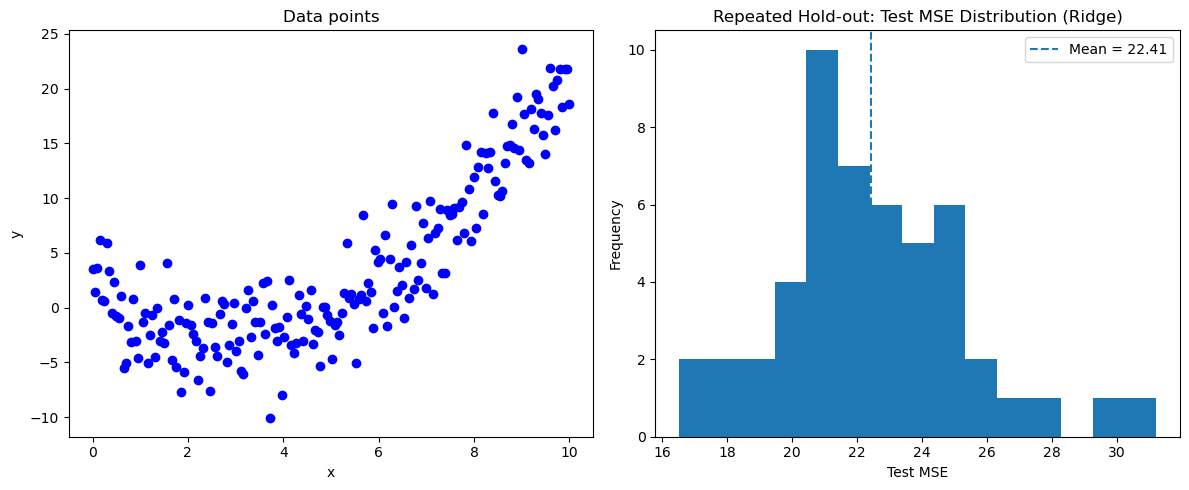

In [7]:
np.random.seed(42)
n = 200
X = np.linspace(0, 10, n).reshape(-1, 1)
y = 0.5 * X.squeeze()**2 - 3 * X.squeeze() + 2 + np.random.randn(n) * 3
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.scatter(X.flatten(),y,c="blue")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Data points")


# Fixed lambda (alpha)
alpha = 10

# Repeated hold-out
n_repeats = 50
test_mse_list = []

for i in range(n_repeats):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True)

    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    y_test_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_test_pred)

    test_mse_list.append(mse)

# Results
mean_mse = np.mean(test_mse_list)
std_mse = np.std(test_mse_list)

print(f"Average Test MSE over {n_repeats} splits: {mean_mse:.3f} => Estimate for Generalization Error")
print(f"Std of Test MSE: {std_mse:.3f} (low variance of predictions)")

# Plot distribution of errors
plt.subplot(1,2,2)
plt.hist(test_mse_list, bins=15)
plt.axvline(mean_mse, linestyle="--", label=f"Mean = {mean_mse:.2f}")
plt.title("Repeated Hold-out: Test MSE Distribution (Ridge)")
plt.xlabel("Test MSE")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

<a class="anchor" id="CV"></a>
### 7.2 k-fold Cross Validation (CV)

- Split data $\mathcal{D}$ into $k$ roughly equally-sized partitions
- Each partition of $\mathcal{D}$ is test set $\mathcal{D}_\text{test}$ once
- Data not in $\mathcal{D}_\text{test}$ is used for training as $\mathcal{D}_\text{train}$
- Aquire $k$ test errors on each test set $\mathcal{D}_\text{test}$ and average them
- Of the data $\mathcal{D}$ approximately $\frac{k-1}{k}$% is used for training

<p align="center">
<img src="pics\5.jpg" width="600"/>
</p>

- More Folds $\Rightarrow$ $\widehat{\text{GE}}$ more unbiased
- k=5 or k=10 folds are common

```python
from sklearn.model_selection import KFold

# X = feature matrix shape (m,n)
# y = target labels shape (m,)

# K-Fold Cross Validation
# Split data into k equally sized folds.
# In each iteration:
#   - 1 fold = validation set
#   - remaining k-1 folds = training set
# Total number of models trained = k

kfold = KFold(
    n_splits=5, # number of folds k
    shuffle=True, # shuffle before splitting
    random_state=1929 # reproducibility
)

for fold, (train_idx, test_idx) in enumerate(kfold.split(X), 1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # fit model on X_train, y_train
    # evaluate on X_test, y_test

# Mathematical idea:
# CV_Error = (1/k) * sum(error_i) for i=1..k
```

In [ ]:
def f():
    yield 1
    yield 2
    yield 3

gen = f()
# each next() resumes the function right after the last yield.
print(next(gen))  # 1
print(next(gen))  # 2
print(next(gen))  # 3

arr = np.arange(0,11)
print(f"Split {arr} into {np.array_split(arr,4)} ")


def simple_kfold_indices(n_samples, k=5, shuffle=True, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)

    # 1. Create indices
    indices = np.arange(n_samples)

    # 2. Shuffle (optional)
    if shuffle:
        np.random.shuffle(indices)

    # 3. Split into k folds
    folds = np.array_split(indices, k)

    # 4. Generate train/test splits
    for i in range(k):
        test_idx = folds[i]
        train_idx = np.hstack([folds[j] for j in range(k) if j != i])
        # yield means give me one (train, test) split, pause, and wait until I ask for the next one (better than return [(train1, test1), (train2, test2), ...])
        yield train_idx, test_idx 
    
X = np.arange(1, 11)
y = 2 * X
print("X=",X, " and y=",y)
for fold, (train_idx, test_idx) in enumerate(simple_kfold_indices(len(X), k=3, random_state=42)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    #print("X_train\n",X_train,"\n")
    #print("y_train\n",y_train,"\n")
    #print("--------------")
    #print("X_test\n",X_test,"\n")
    #print("y_test\n",y_test,"\n")

    print(f"Fold {fold+1}: train={len(train_idx)}, test={len(test_idx)}")

1
2
3
Split [ 0  1  2  3  4  5  6  7  8  9 10] into [array([0, 1, 2]), array([3, 4, 5]), array([6, 7, 8]), array([ 9, 10])] 
X= [ 1  2  3  4  5  6  7  8  9 10]  and y= [ 2  4  6  8 10 12 14 16 18 20]
Fold 1: train=6, test=4
Fold 2: train=7, test=3
Fold 3: train=7, test=3


Fold 1 accuracy: 0.833
Test class distribution per fold: {'Class 0': np.int64(32), 'Class 1': np.int64(28)} 

Fold 2 accuracy: 0.850
Test class distribution per fold: {'Class 0': np.int64(28), 'Class 1': np.int64(32)} 

Fold 3 accuracy: 0.933
Test class distribution per fold: {'Class 0': np.int64(26), 'Class 1': np.int64(34)} 

Fold 4 accuracy: 0.867
Test class distribution per fold: {'Class 0': np.int64(35), 'Class 1': np.int64(25)} 

Fold 5 accuracy: 0.833
Test class distribution per fold: {'Class 0': np.int64(29), 'Class 1': np.int64(31)} 

5-Fold CV Result
Mean accuracy: 0.863
Std: 0.037


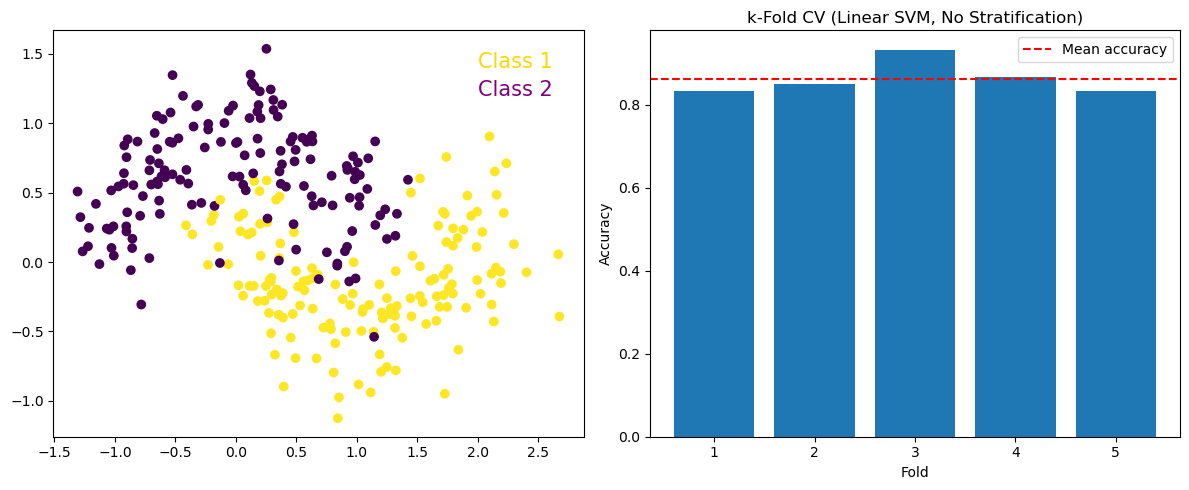

In [ ]:
np.random.seed(42)
X, y = make_moons(n_samples=300, noise=0.25, random_state=1713) # X has 2 columns

plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.scatter(X[:,0],X[:,1],c=y)
plt.text(2,1.4,"Class 1",c="gold",fontsize=15)
plt.text(2,1.2,"Class 2",c="purple",fontsize=15)

# Model 
model = SVC(kernel="linear")

# k-fold CV 
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

fold_accuracies = []

# CV loop 
for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    fold_accuracies.append(acc)

    print(f"Fold {fold + 1} accuracy: {acc:.3f}")
    
    # class distribution per fold
    unique, counts = np.unique(y_test, return_counts=True)
    print("Test class distribution per fold:", dict(zip([f"Class {u}" for u in unique], counts)),"\n")


mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)


print(f"{k}-Fold CV Result")
print(f"Mean accuracy: {mean_acc:.3f}")
print(f"Std: {std_acc:.3f}")


plt.subplot(1,2,2)
plt.bar(range(1, k + 1), fold_accuracies)
plt.axhline(mean_acc, color="red", linestyle="--", label="Mean accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("k-Fold CV (Linear SVM, No Stratification)")
plt.legend()
plt.tight_layout()
plt.show()

<a class="anchor" id="CV_start"></a>
### 7.3 Cross-Validation-Stratification

- Used when target classes are very imbalanced
- Preserve distribution of target (or any feature) in each fold

<p align="center">
<img src="pics\6.png" width="600"/>
</p>

**Example:**
- Assume binary classification:
- class ``+`` = 9 observations $\Rightarrow$ 75% positive
- class ``-`` = 3 observations $\Rightarrow$ 25% negative
- total 12 observation $\Rightarrow$ 3-fold CV with 4 observations per fold optimal here

If we randomly split into 3 folds, one fold might accidentally get:
- 4 positives, 0 negatives and another
- 2 positives, 2 negatives

This makes folds unbalanced and validation scores then fluctuate because some folds are artificially easier/harder.

Stratified splitting means:
- preserve original class ratio inside each fold
- overall ratio is 75/25
- each fold of size 4 should ideally contain:
    - 3 positives
    - 1 negative
    
| Fold   | Positive | Negative |
| ------ | -------- | -------- |
| Fold 1 | 3        | 1        |
| Fold 2 | 3        | 1        |
| Fold 3 | 3        | 1        |

**Now every validation round sees similar class composition.**

**Round 1:** <br>

$\quad$ train on folds 2+3, test on fold1

**Round 2:** <br>

$\quad$ train on folds 1+3, test on fold2

**Round 3:** <br>

$\quad$ train on folds 1+2, test on fold3

Final CV error: $\text{CV}_3 = \frac{1}{3}(\text{Test error}_1+\text{Test error}_2+\text{Test error}_3)$


```python
from sklearn.model_selection import StratifiedKFold

# X = feature matrix shape (m,n)
# y = target labels shape (m,)

# Stratified K-Fold Cross Validation
# Same as K-Fold, but preserves class proportions in every fold.
# Important for imbalanced classification tasks.

skfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for fold, (train_idx, test_idx) in enumerate(skfold.split(X, y), 1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # fit model
    # evaluate model


# Mathematical idea:
# each fold approximately satisfies:
# P(class=c in fold_i) approximately P(class=c in full dataset)
```

Fold 1 accuracy: 0.960
Test class distribution per fold: {'Class 0': np.int64(75), 'Class 1': np.int64(25)} 

Fold 2 accuracy: 0.980
Test class distribution per fold: {'Class 0': np.int64(75), 'Class 1': np.int64(25)} 

Fold 3 accuracy: 0.920
Test class distribution per fold: {'Class 0': np.int64(75), 'Class 1': np.int64(25)} 

Mean CV Accuracy: 0.953
Std CV Accuracy : 0.025


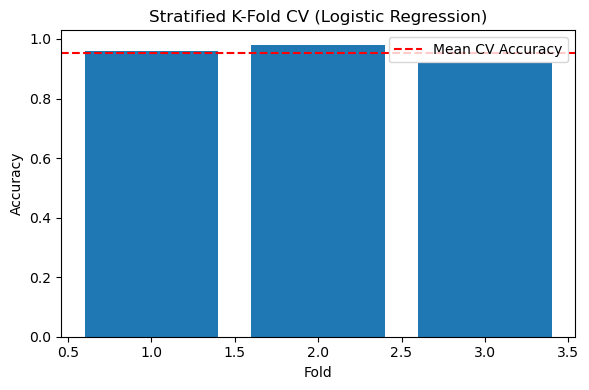

In [ ]:
# Imbalanced dataset
X, y = make_classification(n_samples=300,n_features=2,n_redundant=0,n_clusters_per_class=1,
                           weights=[0.75, 0.25], # imbalanced classes
                           random_state=42)

# Model 
model = LogisticRegression()

# Stratified K-Fold 
k = 3
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

fold_accuracies = []

# CV loop 
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    fold_accuracies.append(acc)

    # class distribution per fold
    unique, counts = np.unique(y_test, return_counts=True)
    print(f"Fold {fold+1} accuracy: {acc:.3f}")
    print("Test class distribution per fold:", dict(zip([f"Class {u}" for u in unique], counts)),"\n")


print(f"Mean CV Accuracy: {np.mean(fold_accuracies):.3f}")
print(f"Std CV Accuracy : {np.std(fold_accuracies):.3f}")


plt.figure(figsize=(6,4))
plt.bar(range(1, k+1), fold_accuracies)
plt.axhline(np.mean(fold_accuracies), color="red", linestyle="--", label="Mean CV Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Stratified K-Fold CV (Logistic Regression)")
plt.legend()
plt.tight_layout()
plt.show()

<a class="anchor" id="LOO-CV"></a>
### 7.4 Leave-one-out CV (LOO-CV)

- $(x_i,y_i) = \left((x_{i1},x_{i2},\ldots,x_{ip}),y_i\right)$ for $i=1,\ldots,n$

$$
\left.
\begin{array}{rcl}
\text{Iter 1:}& \text{data }\mathcal{D} &\{\overbrace{{\color{green}{(x_1,y_1)}},{\color{green}{(x_2,y_2)}},{\color{green}{(x_3,y_3)}},\ldots,{\color{green}{(x_{n-1},y_{n-1})}}}^{\color{green}\mathcal{D}_\text{train}},\overbrace{{\color{red}{(x_n,y_n)}}}^{\color{red}\mathcal{D}_\text{test}}\} &\Rightarrow \text{Test error 1} \\

\text{Iter 2:}& \text{data }\mathcal{D} &\{{\color{red}{(x_1,y_1)}},{\color{green}{(x_2,y_2)}},{\color{green}{(x_3,y_3)}},\ldots,{\color{green}{(x_{n-1},y_{n-1})}},{\color{green}{(x_n,y_n)}}\} &\Rightarrow \text{Test error 2} \\ 

\text{Iter 3:}& \text{data }\mathcal{D} &\{{\color{green}{(x_1,y_1)}},{\color{red}{(x_2,y_2)}},{\color{green}{(x_3,y_3)}},\ldots,{\color{green}{(x_{n-1},y_{n-1})}},{\color{green}{(x_n,y_n)}}\} &\Rightarrow \text{Test error 3} \\

\vdots & & \vdots & \vdots \\

\text{Iter n:}& \text{data }\mathcal{D} &\{{\color{green}{(x_1,y_1)}},{\color{green}{(x_2,y_2)}},{\color{green}{(x_3,y_3)}},\ldots,{\color{red}{(x_{n-1},y_{n-1})}},{\color{green}{(x_n,y_n)}}\} &\Rightarrow \text{Test error n} \\

\end{array}
\right\} \text{Average}
$$

**LOO $\Rightarrow$ High variance**

```python
from sklearn.model_selection import LeaveOneOut


# X = feature matrix shape (m,n)
# y = target labels shape (m,)


# Leave-One-Out Cross Validation (LOO CV)
# Special case of K-Fold with k = m (number of samples)
# Each iteration:
#   - exactly 1 observation used as test set
#   - all others used for training
# Total number of models trained = m

loo = LeaveOneOut()

for fold, (train_idx, test_idx) in enumerate(loo.split(X), 1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # fit model
    # evaluate model


# Mathematical idea:
# LOO_Error = (1/m) * sum(error_i) for i=1..m

# Pros:
# - maximal training data used each iteration
# Cons:
# - computationally expensive for large m

```

LOO-CV Accuracy: 0.950
Number of folds: 80


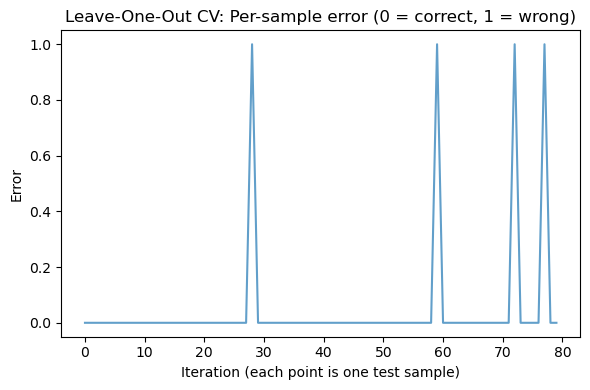

In [ ]:
np.random.seed(42)
X, y = make_classification(
    n_samples=80, # keep small -> LOO is expensive otherwise
    n_features=5,n_informative=3,n_redundant=0,random_state=42)

# Model
model = GaussianNB()

# Leave-One-Out CV 
loo = LeaveOneOut() # alternative KFold(n_splits=X.shape[0], shuffle=False)

correct = 0
n_folds = 0
errors = []

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx] # X_test is one observation of 5 features
    y_train, y_test = y[train_idx], y[test_idx] # y_test is a single value

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    correct += (pred[0] == y_test[0]) # use pred[0] and y_test[0] instead of pred and y_test since it gets the scalar
    errors.append(int(pred[0] != y_test[0]))

    n_folds += 1


accuracy = correct / n_folds

print(f"LOO-CV Accuracy: {accuracy:.3f}")
print(f"Number of folds: {n_folds}")


# Plot error pattern 
plt.figure(figsize=(6, 4))
plt.plot(errors, alpha=0.7)
plt.title("Leave-One-Out CV: Per-sample error (0 = correct, 1 = wrong)")
plt.xlabel("Iteration (each point is one test sample)")
plt.ylabel("Error")
plt.tight_layout()
plt.show()

<a class="anchor" id="LOOO"></a>
### 7.5 Leave-one-object-out

**Situation:** We have clusters of observations from the same objects
- e.g. multiple medical images from same patient

**Problem:** 
- Data is no longer i.i.d.
- Data from same object might appear in both train and testset $\Rightarrow$ Test error unrealistically low (bias $\widehat{\text{GE}}$ and **data leakage**)
- Data from same object should either be in train or testset

<p align="center">
<img src="pics\7.png" width="600"/>
</p>

```python
from sklearn.model_selection import LeaveOneGroupOut  

# X = feature matrix shape (m,n)
# y = target labels shape (m,)
# groups = group labels shape (m,) for grouped CV


# Leave-One-Group-Out Cross Validation (LOGO CV)
# Entire groups are left out together.
# Useful when observations inside a group are dependent
# (e.g. same patient, same user, same time period).

logo = LeaveOneGroupOut()

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups=groups), 1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # fit model
    # evaluate model


# Mathematical idea:
# if there are G unique groups:
# CV_Error = (1/G) * sum(error_group_i)

# Guarantees:
# all samples from one group are either
# entirely in train OR entirely in test

```

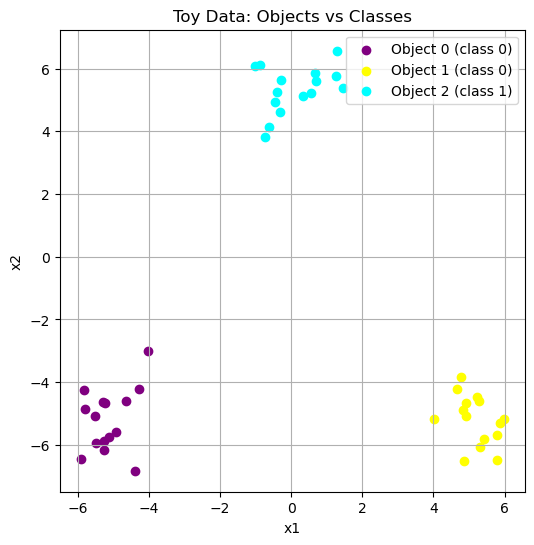

Standard KFold (leakage!)
Mean accuracy: 1.000

Leave-One-Object-Out (Group CV)
Mean accuracy: 0.667


In [ ]:
np.random.seed(1846)

# Create 3 objects (clusters) 
n_objects = 3
samples_per_object = 15

X_list = []
y_list = []
groups = []

centers = np.array([[-5, -4],[5, -5],[2, 5]])

# Assign labels per object (not equal to object id)
# e.g. two clusters same class, one different
object_labels = [0, 0, 1]

for obj in range(n_objects):
    center = centers[obj]

    for _ in range(samples_per_object):
        x = center + np.random.randn(2) * 0.8
        y = object_labels[obj]

        X_list.append(x)
        y_list.append(y)
        groups.append(obj)

X = np.array(X_list)
y = np.array(y_list)
groups = np.array(groups)

# Plot
plt.figure(figsize=(6,6))
colors = ["purple", "yellow", "cyan"]

for obj in range(n_objects):
    plt.scatter(X[groups == obj, 0],X[groups == obj, 1],label=f"Object {obj} (class {object_labels[obj]})",color=colors[obj])

plt.title("Toy Data: Objects vs Classes")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()

# Model 
model = RandomForestClassifier(random_state=42)


# Standard KFold (leakage)
kf = KFold(n_splits=3, shuffle=True, random_state=42)
acc_kfold = []

for train_idx, test_idx in kf.split(X):
    model.fit(X[train_idx], y[train_idx])
    preds = model.predict(X[test_idx])
    acc_kfold.append(accuracy_score(y[test_idx], preds))

print("Standard KFold (leakage!)")
print(f"Mean accuracy: {np.mean(acc_kfold):.3f}\n")


# Leave-One-Object-Out
logo = LeaveOneGroupOut()
acc_logo = []

for train_idx, test_idx in logo.split(X, y, groups):
    model.fit(X[train_idx], y[train_idx])
    preds = model.predict(X[test_idx])
    acc_logo.append(accuracy_score(y[test_idx], preds))

print("Leave-One-Object-Out (Group CV)")
print(f"Mean accuracy: {np.mean(acc_logo):.3f}")

<a class="anchor" id="bootstrap"></a>
### 7.6 Bootstrap

- $\mathcal{D}$=data set of size $n$
- Draw $B$ trainsets $\mathcal{D}_\text{train}^b$ of size $n$ with replacement from $\mathcal{D}$
- Because of replacement, some data points appear multiple times in the same set
- Train model on $\mathcal{D}_\text{train}^b$ and test on Out-of-Bag (OOB) points $\mathcal{D}_\text{test}^b=\mathcal{D}$ \ $\mathcal{D}_\text{train}^b$
- Each bootstrap sample $\mathcal{D}_\text{train}^b$ of size $n$ includes on average $1-P((x,y) \notin \mathcal{D}_\text{train})=1-(1-\frac{1}{n})^n \overset{n \rightarrow \infty}{\longrightarrow}1-\frac{1}{e} \approx 63.2$% unique points

<p align="center">
<img src="pics\8.png" width="400"/>
</p>


Average OOB MSE: 0.166
Std OOB MSE: 0.036
Average unique sample ratio: 0.639


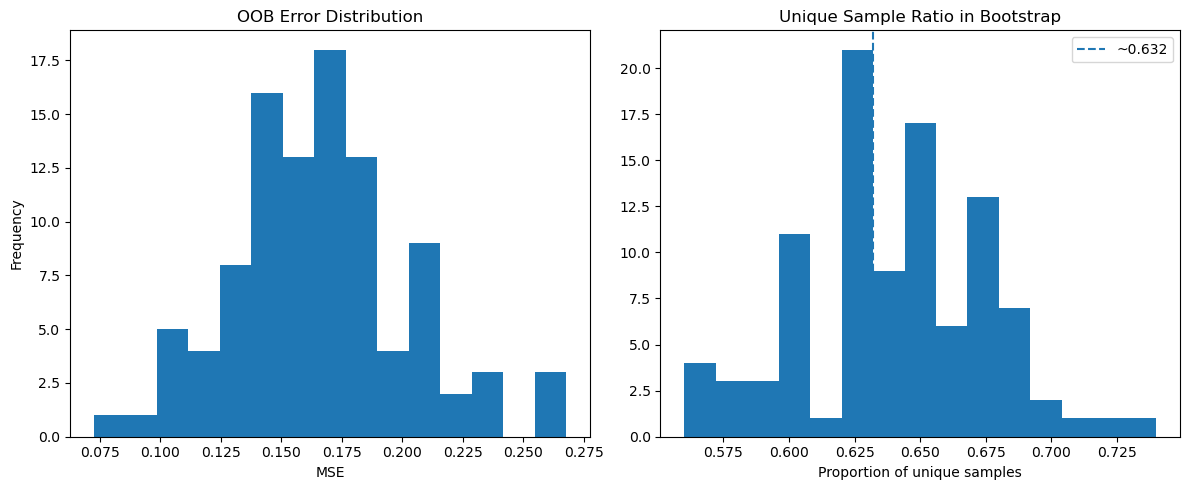

In [18]:
np.random.seed(1918)

# Generate regression data
n = 100
X = np.linspace(0, 10, n).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.randn(n) * 0.3

# Bootstrap parameters 
B = 100 # number of bootstrap samples

oob_errors = []
unique_ratios = []

for b in range(B):
    # Bootstrap sampling with replacement
    indices = np.random.choice(n, size=n, replace=True)

    X_train = X[indices]
    y_train = y[indices]

    # OOB samples (not selected in respective Bootstrap sample)
    oob_mask = np.ones(n, dtype=bool)
    oob_mask[indices] = False

    X_oob = X[oob_mask]
    y_oob = y[oob_mask]

    # Track unique proportion
    unique_ratio = len(np.unique(indices)) / n
    unique_ratios.append(unique_ratio)

    # Skip if no OOB samples (rare but possible)
    if len(X_oob) == 0:
        continue

    # Train model
    model = DecisionTreeRegressor()
    model.fit(X_train, y_train)

    # Evaluate on OOB 
    preds = model.predict(X_oob)
    mse = mean_squared_error(y_oob, preds)
    oob_errors.append(mse)

# Results 
print(f"Average OOB MSE: {np.mean(oob_errors):.3f}")
print(f"Std OOB MSE: {np.std(oob_errors):.3f}")
print(f"Average unique sample ratio: {np.mean(unique_ratios):.3f}")

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of OOB errors
axes[0].hist(oob_errors, bins=15)
axes[0].set_title("OOB Error Distribution")
axes[0].set_xlabel("MSE")
axes[0].set_ylabel("Frequency")

# Unique sample ratio
axes[1].hist(unique_ratios, bins=15)
axes[1].axvline(1 - 1/np.e, linestyle="--", label="~0.632")
axes[1].set_title("Unique Sample Ratio in Bootstrap")
axes[1].set_xlabel("Proportion of unique samples")
axes[1].legend()

plt.tight_layout()
plt.show()

<a class="anchor" id="bootstrap"></a>
#### Short Guideline

- 5-fold or 10-fold CV is standard
- For small $n$ do not use hold-out, CV with few folds or Subsampling with small split rate
- For $n < 200$ use Leave-one-out or repeated CV
- Subsampling often better than bootstrapping 

<a class="anchor" id="metric"></a>
# 8. Choosing the right metric

- No single "best" metric
- Depends on application context:
    - Medical $\rightarrow$ prioritize recall (TPR)
    - Finance $\rightarrow$ balance risk vs reward
- Different metrics $\rightarrow$ different model rankings

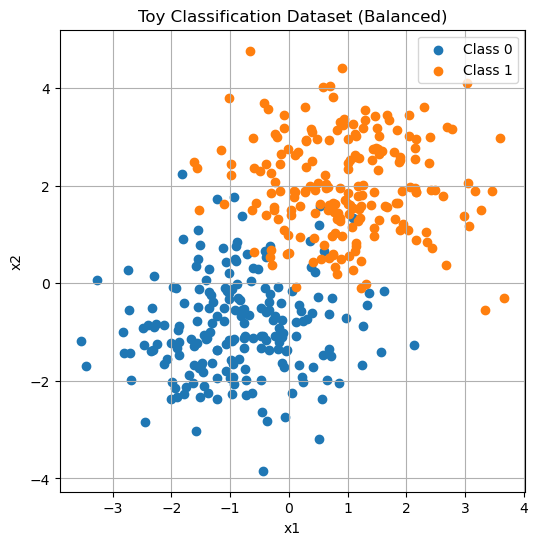


K-Fold CV Results

Random Forest            : 0.953
Decision Tree            : 0.922
Logistic Reg             : 0.955
k-NN                     : 0.938
SVM                      : 0.953
Naive Bayes              : 0.955


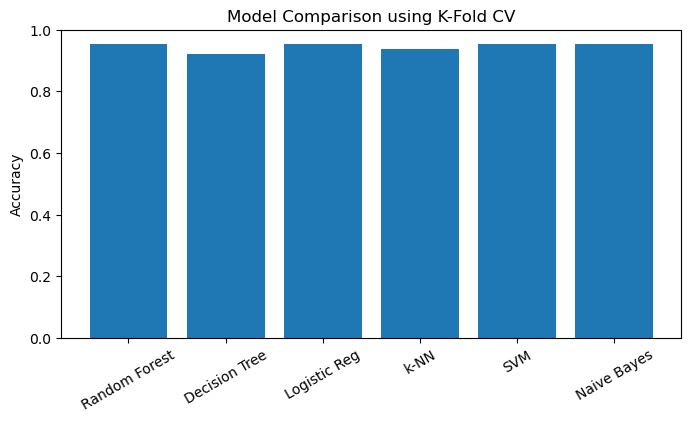

In [32]:
# Decison Tree Classifier
# Logistic Regression
# k-NN
# linear nonseparable SVM
# Naive Bayes

np.random.seed(1954)

n = 400 # total samples (balanced)

# Class 0
X0 = np.random.randn(n//2, 2) + np.array([-1, -1])
y0 = np.zeros(n//2)

# Class 1
X1 = np.random.randn(n//2, 2) + np.array([1, 2])
y1 = np.ones(n//2)

# Combine
X = np.vstack([X0, X1])
y = np.hstack([y0, y1])

plt.figure(figsize=(6,6))

plt.scatter(X[y==0][:,0], X[y==0][:,1], label="Class 0")
plt.scatter(X[y==1][:,0], X[y==1][:,1], label="Class 1")

plt.title("Toy Classification Dataset (Balanced)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid()
plt.show()

models = {"Random Forest": RandomForestClassifier(n_estimators=100, random_state=1959),
          "Decision Tree": DecisionTreeClassifier(max_depth=10),
          "Logistic Reg": LogisticRegression(max_iter=1000),
          "k-NN": KNeighborsClassifier(n_neighbors=3),
          "SVM": SVC(kernel="linear",C=3),
          "Naive Bayes": GaussianNB()}

kf = KFold(n_splits=5, shuffle=True, random_state=1955)

results = {}

for name, model in models.items():
    fold_scores = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        acc = accuracy_score(y_test, preds)
        fold_scores.append(acc)

    results[name] = np.mean(fold_scores)

print("\nK-Fold CV Results\n")

for name, score in results.items():
    print(f"{name:25s}: {score:.3f}")

plt.figure(figsize=(8,4))

names = list(results.keys())
scores = list(results.values())

plt.bar(names, scores)
plt.ylabel("Accuracy")
plt.title("Model Comparison using K-Fold CV")
plt.xticks(rotation=30)
plt.ylim(0, 1)

plt.show()

<a class="anchor" id="extra"></a>
# 9. Confusion matrix, ROC and AUC